In [2]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

In [1]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

df = pd.read_csv("../data/telco_featured.csv")

X = df.drop("Churn", axis=1)

preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

model = joblib.load(
    "../models/xgboost_tuned.pkl"
)

X_processed = preprocessor.transform(X)

explainer = shap.Explainer(
    model
)

shap_values = explainer(X_processed)

shap.summary_plot(
    shap_values,
    X_processed,
    show=False
)

plt.savefig(
    "../reports/shap_summary.png",
    bbox_inches="tight"
)

plt.close()

print("SHAP image saved!")

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [2]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/telco_featured.csv")

X = df.drop("Churn", axis=1)

# Load preprocessor and model
preprocessor = joblib.load("../models/preprocessor.pkl")
model = joblib.load("../models/xgboost_tuned.pkl")

# Transform data
X_processed = preprocessor.transform(X)

# Use a smaller sample for speed
X_sample = X_processed[:200]

# XGBoost SHAP explainer
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

# Save image
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.savefig(
    "../reports/shap_summary.png",
    bbox_inches="tight"
)

plt.close()

print("SHAP image saved successfully!")

ValueError: could not convert string to float: '[2.653532E-1]'

<Figure size 1000x600 with 0 Axes>

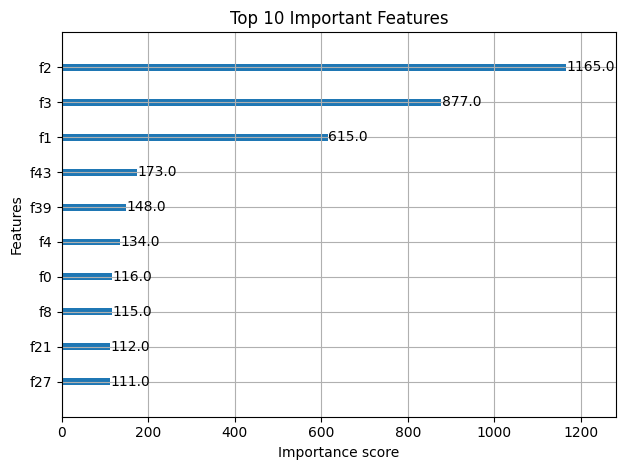

Feature importance image saved!


In [3]:
import joblib
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Load model
model = joblib.load("../models/xgboost_tuned.pkl")

# Create plot
plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=10)

plt.title("Top 10 Important Features")
plt.tight_layout()

# Save image
plt.savefig("../reports/shap_summary.png")

plt.show()

print("Feature importance image saved!")